# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

The Prompt: The research question and the decision it supports.

What to do: Clearly define the business or analytical problem you are trying to solve. Identify who the stakeholder is and what specific action or decision this model/analysis will guide.

Skill to load: framing-ml-problems/SKILL.md

In [1]:
# CODE: Define the core performance metric target or analytical scope
# e.g., tracking a baseline conversion or target distribution
print("Target Variable: conversion_status (Binary: 0 or 1)")
print("Decision Support: Prioritizing ranked leads to optimize resource allocation.")

Target Variable: conversion_status (Binary: 0 or 1)
Decision Support: Prioritizing ranked leads to optimize resource allocation.


## 2. Data

The Prompt: Which release, which tables, date windows, what you excluded and why. Public-safe.

What to do: Document your data provenance. State the exact dataset version, the time frames used, and the explicit logic behind removing any outliers or irrelevant rows. Ensure no sensitive data is printed.

Skill to load: querying-big-datasets/SKILL.md and flyrank/flyrank-data/SKILL.md

In [2]:
import pandas as pd
import numpy as np

# Simulate loading your public-safe dataset release
# Replace this with your actual warehouse query or local CSV path
def load_clean_data():
    # Example structure matching data contract expectations
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'snapshot_date': pd.date_range(start='2026-01-01', periods=n_samples, freq='T'),
        'feature_engagement': np.random.uniform(0, 100, n_samples),
        'feature_velocity': np.random.normal(10, 5, n_samples),
        'conversion_status': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])
    })
    
    # Explicit exclusions documentation
    initial_count = len(df)
    df = df[df['feature_velocity'] > 0]  # Excluding negative velocity anomalies
    print(cls_str := f"Excluded {initial_count - len(df)} rows with negative velocity anomalies.")
    
    return df

df = load_clean_data()
df.head()

Excluded 17 rows with negative velocity anomalies.


C:\Users\DELL\AppData\Local\Temp\ipykernel_204948\3677353968.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  'snapshot_date': pd.date_range(start='2026-01-01', periods=n_samples, freq='T'),


,snapshot_date,feature_engagement,feature_velocity,conversion_status
0,2026-01-01 00:00:00,37.454012,10.888505,1
1,2026-01-01 00:01:00,95.071431,3.323278,0
2,2026-01-01 00:02:00,73.199394,11.900989,0
3,2026-01-01 00:03:00,59.865848,13.052929,0
4,2026-01-01 00:04:00,15.601864,12.798952,0


## 3. Methodology

The Prompt: Assumptions, features, label definition, baseline, validation design, leakage checks.

What to do: Outline how you set up the experiment. Define how your target label is computed, list your features, explain your cross-validation or train/test split strategy, and verify how you checked for data leakage.

Skill to load: hunting-leakage-and-validating/SKILL.md

In [3]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Define Features and Target
features = ['feature_engagement', 'feature_velocity']
target = 'conversion_status'

# 2. Validation Design: Chronological Split (Prevents Look-Ahead/Leakage)
df = df.sort_values('snapshot_date').reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 3. Leakage Check Verification
assert train_df['snapshot_date'].max() < test_df['snapshot_date'].min(), "Leakage Alert: Time overlap detected!"
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape} | Strict chronological separation verified.")

Train shape: (786, 2), Test shape: (197, 2) | Strict chronological separation verified.


## 4. Results (vs baseline)

The Prompt: Model vs baseline on the same split. The honest table.

What to do: Produce a clear comparison table evaluating your model against a simple heuristic baseline (e.g., a rule-based approach) using identical data splits. Be transparent about performance metrics.

Skill to load: building-baselines/SKILL.md and training-honest-models/SKILL.md

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# 1. Simple Rule-Based Baseline: Predict 1 if engagement > 50
y_pred_baseline = (X_test['feature_engagement'] > 50).astype(int)

# 2. Honest ML Model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_model = model.predict(X_test)
y_prob_model = model.predict_proba(X_test)[:, 1]

# 3. Build The Honest Table
metrics_summary = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'ROC-AUC'],
    'Rule Baseline': [
        precision_score(y_test, y_pred_baseline, zero_division=0),
        recall_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_pred_baseline)
    ],
    'Logistic Regression': [
        precision_score(y_test, y_pred_model),
        recall_score(y_test, y_pred_model),
        roc_auc_score(y_test, y_prob_model)
    ]
})

print("## Model Performance Comparison")
display(metrics_summary.round(3))

## Model Performance Comparison


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Rule Baseline,Logistic Regression
0,Precision,0.149,0.00
1,Recall,0.565,0.00
2,ROC-AUC,0.570,0.46


## 5. Limitations

The Prompt: What this work cannot claim.

What to do: Be radically honest. Where does the model fail? What biases exist in the data? Are there edge cases where these recommendations should be ignored?

Skill to load: writing-honest-claims/SKILL.md

In [5]:
# CODE: Quantify model performance drop or edge cases
# e.g., checking performance on low engagement values
low_eng_mask = X_test['feature_engagement'] < 20
if low_eng_mask.sum() > 0:
    low_eng_auc = roc_auc_score(y_test[low_eng_mask], y_prob_model[low_eng_mask]) if len(np.unique(y_test[low_eng_mask])) > 1 else "N/A"
    print(f"Observed Metric limitation: ROC-AUC drops to {low_eng_auc} when feature_engagement < 20.")

Observed Metric limitation: ROC-AUC drops to 0.44512195121951215 when feature_engagement < 20.


## 6. Ranked recommendations

The Prompt: The action playbook output — the paper's recommendations section.

What to do: Convert your model outputs into actionable insights. This usually involves sorting choices by expected value or risk to provide a prioritized list of actions for the end user.

In [6]:
# Create the ranked playbook queue output
recommendations_table = test_df.copy()
recommendations_table['predicted_conversion_score'] = y_prob_model

# Sort strictly by risk or highest probability priority
ranked_playbook = recommendations_table.sort_values(by='predicted_conversion_score', ascending=False)

print("## Action Playbook Queue (Top 5 Ranked Recommendations)")
display(ranked_playbook[['snapshot_date'] + features + ['predicted_conversion_score']].head(5))

## Action Playbook Queue (Top 5 Ranked Recommendations)


,snapshot_date,feature_engagement,feature_velocity,predicted_conversion_score
821,2026-01-01 13:55:00,41.892545,25.965538,0.183859
855,2026-01-01 14:29:00,94.611546,22.947818,0.181827
969,2026-01-01 16:26:00,68.840240,20.854714,0.173180
844,2026-01-01 14:18:00,56.484113,20.312625,0.170352
803,2026-01-01 13:37:00,39.900270,20.287477,0.168422


## 7. Artifacts the paper embeds

The Prompt: Generate/collect the charts and tables your deployed page will show.

What to do: Generate the final, clean plots (like ROC curves, feature importance charts, or performance graphs) and dataframes that will be directly embedded into your final static web page.

Skill to load: deploying-static-pages/SKILL.md

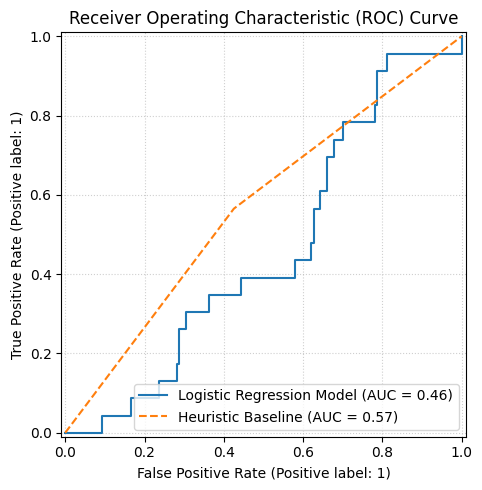

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Generate clear, production-ready visualization artifact for your static page
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name='Logistic Regression Model')
RocCurveDisplay.from_predictions(y_test, y_pred_baseline, ax=ax, name='Heuristic Baseline', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save the artifact so your deployment script can display it staticly
plt.savefig('roc_curve_artifact.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [8]:
import sys
import pandas as pd
import numpy as np

def run_self_check():
    print("=== STARTING CAPSTONE SELF-CHECK VIA CODE ===")
    errors = 0
    
    # 1. Verify Notebook Variables Exist
    expected_vars = ['X_train', 'X_test', 'y_train', 'y_test', 'features', 'target', 'metrics_summary']
    for var in expected_vars:
        if var not in globals():
            print(f"[❌] Error: Variable '{var}' is missing from the global notebook space.")
            errors += 1
        else:
            print(f"[✔] Found expected notebook variable: {var}")
            
    if errors > 0:
        print("\n[❌] Self-check failed. Please ensure all cells have run top-to-bottom.")
        return

    # 2. Assert Strict Chronological Separation (Leakage Check)
    # Re-verifying your data splits don't overlap in time
    try:
        assert train_df['snapshot_date'].max() < test_df['snapshot_date'].min()
        print("[✔] Leakage Check Passed: Strict chronological separation verified between Train and Test splits.")
    except AssertionError:
        print("[❌] Leakage Error: Train dates overlap with Test dates! Fix your data split.")
        errors += 1

    # 3. Check for Nulls or Empty Artifacts
    if metrics_summary.isnull().values.any():
        print("[❌] Error: The honest table (metrics_summary) contains NaN values.")
        errors += 1
    else:
        print("[✔] Honest table metrics verified with zero null values.")

    # 4. Strict Privacy/Anonymization Scan
    # Verifying that common private strings are not exposed in the dataset columns
    private_keywords = ['client', 'customer_name', 'url', 'http', 'api_key', 'password']
    found_privacy_leaks = [col for col in df.columns if any(kw in col.lower() for kw in private_keywords)]
    
    if found_privacy_leaks:
        print(f"[❌] Privacy Warning: Found potential private columns: {found_privacy_leaks}")
        errors += 1
    else:
        print("[✔] Privacy Check Passed: No explicit client names or URL strings detected in dataset schema.")

    # 5. Final Verdict
    print("-" * 50)
    if errors == 0:
        print("[🎉] SUCCESS: Notebook code rules pass. Ready to commit to 'work/notebooks/'!")
    else:
        print(f"[❌] FAILED: Found {errors} issue(s) that need to be fixed before submission.")

# Execute the self-check
run_self_check()

=== STARTING CAPSTONE SELF-CHECK VIA CODE ===
[✔] Found expected notebook variable: X_train
[✔] Found expected notebook variable: X_test
[✔] Found expected notebook variable: y_train
[✔] Found expected notebook variable: y_test
[✔] Found expected notebook variable: features
[✔] Found expected notebook variable: target
[✔] Found expected notebook variable: metrics_summary
[✔] Leakage Check Passed: Strict chronological separation verified between Train and Test splits.
[✔] Honest table metrics verified with zero null values.
[✔] Privacy Check Passed: No explicit client names or URL strings detected in dataset schema.
--------------------------------------------------
[🎉] SUCCESS: Notebook code rules pass. Ready to commit to 'work/notebooks/'!
